In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import pyarrow as pa

from shapely.geometry import box

### Reading the DataFrames

In [2]:
# Reading xlsx files
# Fires from 2011 to 2020
df_2011_2020 = pd.read_excel("../data/raw/Registos_Incendios_SGIF_2011_2020.xlsx")

# Fires from 2021 up to 2025 (most recent data)
df_2021_2025 = pd.read_excel("../data/raw/Registos_Incendios_SGIF_2021_2025.xlsx")

In [3]:
print(df_2011_2020.head())
print(f"\n Dataframe shape: \n {df_2011_2020.shape}")

  Codigo_SGIF  Codigo_ANEPC   Ano  Mes  Dia  Hora  AreaPov_ha  AreaMato_ha  \
0      DM2111           368  2011    1    1    17         0.0        0.010   
1      BL4112          1236  2011    1    9    22         0.0        0.000   
2      DM3111           820  2011    1   15    17         0.0        0.000   
3      BL2111          1977  2011    1   18    22         0.0        0.001   
4      DM2113          7930  2011    1   19    17         0.0        0.005   

   AreaAgric_ha  AreaTotal_ha  ...       ISI         DC       DMC       FFMC  \
0       0.00000       0.01000  ...  0.291930   4.092373  0.653638  54.525424   
1       0.00200       0.00200  ...  0.013831   1.835452  0.367371  32.001278   
2       0.00001       0.00001  ...  1.171990   9.658571  1.573768  74.889775   
3       0.00000       0.00100  ...  0.248910  12.477199  0.762519  51.102608   
4       0.00000       0.00500  ...  0.008092   3.968661  0.508191  32.290416   

        BUI  CodCausa     TipoCausa  \
0  0.934234

In [4]:
print(df_2021_2025.head())
print(f"\n Dataframe shape:\n {df_2021_2025.shape}")

  Codigo_SGIF   Codigo_ANEPC   Ano  Mes  Dia  Hora  AreaPov_ha  AreaMato_ha  \
0      BL3212  2021010001353  2021    1    5    15         0.0        0.000   
1      TM1213  2021170000717  2021    1    7    14         0.0        0.010   
2      BL1214  2021180001261  2021    1    7    18         0.0        0.680   
3      BL1215  2021180001268  2021    1    7    18         0.0        3.320   
4      TM2212  2021040000721  2021    1    7    18         0.0        0.003   

   AreaAgric_ha  AreaTotal_ha  ...       ISI        DC       DMC       FFMC  \
0        0.0123        0.0123  ...  0.697716  2.889986  0.776699  65.581411   
1        0.0000        0.0100  ...  1.579420  3.718020  1.333320  80.617788   
2        0.0000        0.6800  ...  1.817733  5.185042  1.513554  78.676647   
3        0.0000        3.3200  ...  1.500755  3.849406  1.232262  77.484526   
4        0.0000        0.0030  ...  1.615021  2.430952  1.077586  78.561693   

        BUI  CodCausa    TipoCausa  \
0  0.929128 

In [5]:
# Checking if both dataframes have same column names
df_2021_2025.columns.equals(df_2011_2020.columns)

True

In [6]:
print(f"""
    2011 to 2020 data types: \n {df_2011_2020.dtypes} \n \n
    2021 to 2025 data types: \n {df_2021_2025.dtypes}""")


    2011 to 2020 data types: 
 Codigo_SGIF                                str
Codigo_ANEPC                             int64
Ano                                      int64
Mes                                      int64
Dia                                      int64
Hora                                     int64
AreaPov_ha                             float64
AreaMato_ha                            float64
AreaAgric_ha                           float64
AreaTotal_ha                           float64
ClasseArea                                 str
DataHoraAlerta                  datetime64[us]
DataHora_PrimeiraIntervencao    datetime64[us]
DataHora_Extincao               datetime64[us]
Duracao_Horas                          float64
IncSup24horas                            int64
DTCCFR                                   int64
Distrito                                   str
Concelho                                   str
Freguesia                                  str
Local                       

### Concatenating both dataframes

In [7]:
# Concatenating both dataframes

fires = pd.concat([df_2011_2020, df_2021_2025])

print(f"""
    {fires.head()} \n
    Fires Shape: {fires.shape} \n
    Fires DTypes: {fires.dtypes}""")


      Codigo_SGIF  Codigo_ANEPC   Ano  Mes  Dia  Hora  AreaPov_ha  AreaMato_ha  \
0      DM2111           368  2011    1    1    17         0.0        0.010   
1      BL4112          1236  2011    1    9    22         0.0        0.000   
2      DM3111           820  2011    1   15    17         0.0        0.000   
3      BL2111          1977  2011    1   18    22         0.0        0.001   
4      DM2113          7930  2011    1   19    17         0.0        0.005   

   AreaAgric_ha  AreaTotal_ha  ...       ISI         DC       DMC       FFMC  \
0       0.00000       0.01000  ...  0.291930   4.092373  0.653638  54.525424   
1       0.00200       0.00200  ...  0.013831   1.835452  0.367371  32.001278   
2       0.00001       0.00001  ...  1.171990   9.658571  1.573768  74.889775   
3       0.00000       0.00100  ...  0.248910  12.477199  0.762519  51.102608   
4       0.00000       0.00500  ...  0.008092   3.968661  0.508191  32.290416   

        BUI  CodCausa     TipoCausa  \
0  0.9

### Filtering 2017-2025

In [8]:
# Filtering fires between 2017 to 2025
fires_2017_2025_raw  = fires[fires["Ano"].between(2017,2025)]
print(f"\n DataFrame Shape: {fires_2017_2025_raw.shape}")
fires_2017_2025_raw.head()


 DataFrame Shape: (94337, 41)


,Codigo_SGIF,Codigo_ANEPC,Ano,Mes,Dia,Hora,AreaPov_ha,AreaMato_ha,AreaAgric_ha,AreaTotal_ha,...,ISI,DC,DMC,FFMC,BUI,CodCausa,TipoCausa,GrupoCausa,DescricaoCausa,FonteAlerta
123398,DM4171,2017030000006,2017,1,1,0,0.000,0.0100,0.0,0.0100,...,2.579540,26.225379,7.648318,85.187608,8.846614,60.0,Desconhecida,Indeterminadas,Indeterminadas,Populares
123399,BL3172,2017010000004,2017,1,1,0,0.000,0.0010,0.0,0.0010,...,2.652681,97.852669,8.396711,84.692546,13.827160,610.0,Desconhecida,Indeterminadas,Indeterminadas - Prova material,CCO
123400,RO2171,2017110000013,2017,1,1,0,0.000,0.0195,0.0,0.0195,...,2.640921,185.333806,6.343408,82.002968,11.686807,630.0,Desconhecida,Indeterminadas,Indeterminadas - Outras informações,112
123401,BL3171,2017010000007,2017,1,1,0,0.075,0.0000,0.0,0.0750,...,2.456941,26.463073,6.418945,83.327931,7.991686,6.0,Desconhecida,Indeterminadas,Indeterminadas,117
123402,DM4173,2017030000139,2017,1,1,12,0.000,0.0100,0.0,0.0100,...,2.659881,29.462939,7.738363,83.253734,9.342361,60.0,Desconhecida,Indeterminadas,Indeterminadas,117


# Basic Data Cleaning

In [9]:
fires_2017_2025 = fires_2017_2025_raw.copy()

fires_2017_2025.dtypes

Codigo_SGIF                             object
Codigo_ANEPC                             int64
Ano                                      int64
Mes                                      int64
Dia                                      int64
Hora                                     int64
AreaPov_ha                             float64
AreaMato_ha                            float64
AreaAgric_ha                           float64
AreaTotal_ha                           float64
ClasseArea                                 str
DataHoraAlerta                  datetime64[us]
DataHora_PrimeiraIntervencao    datetime64[us]
DataHora_Extincao               datetime64[us]
Duracao_Horas                          float64
IncSup24horas                            int64
DTCCFR                                 float64
Distrito                                   str
Concelho                                   str
Freguesia                                  str
Local                                   object
RNAP         

In [10]:
fires_2017_2025.columns

Index(['Codigo_SGIF', 'Codigo_ANEPC', 'Ano', 'Mes', 'Dia', 'Hora',
       'AreaPov_ha', 'AreaMato_ha', 'AreaAgric_ha', 'AreaTotal_ha',
       'ClasseArea', 'DataHoraAlerta', 'DataHora_PrimeiraIntervencao',
       'DataHora_Extincao', 'Duracao_Horas', 'IncSup24horas', 'DTCCFR',
       'Distrito', 'Concelho', 'Freguesia', 'Local', 'RNAP', 'RNMPF',
       'X_Militar', 'Y_Militar', 'Latitude', 'Longitude', 'X_ETRS89',
       'Y_ETRS89', 'DSR', 'FWI', 'ISI', 'DC', 'DMC', 'FFMC', 'BUI', 'CodCausa',
       'TipoCausa', 'GrupoCausa', 'DescricaoCausa', 'FonteAlerta'],
      dtype='str')

In [11]:
fires_2017_2025['Distrito'].unique()

<ArrowStringArray>
[           'Braga',           'Aveiro',           'Lisboa',
            'Porto',        'Vila Real',            'Viseu',
           'Guarda', 'Viana do Castelo',          'Coimbra',
          'Setúbal',           'Leiria',   'Castelo Branco',
         'Bragança',       'Portalegre',         'Santarém',
             'Faro',             'Beja',            'Évora',
 'Viana Do Castelo',                nan]
Length: 20, dtype: str

In [12]:
# Since there is 'Viana do Castelo' and 'Viana Do Castelo' , let's make them equal
 

fires_2017_2025['Distrito'] = fires_2017_2025['Distrito'].replace({
    "Viana Do Castelo": "Viana do Castelo"})

fires_2017_2025.isna().sum()

Codigo_SGIF                         0
Codigo_ANEPC                        0
Ano                                 0
Mes                                 0
Dia                                 0
Hora                                0
AreaPov_ha                          0
AreaMato_ha                         0
AreaAgric_ha                        0
AreaTotal_ha                        0
ClasseArea                          0
DataHoraAlerta                      0
DataHora_PrimeiraIntervencao      378
DataHora_Extincao                 235
Duracao_Horas                     235
IncSup24horas                       0
DTCCFR                              1
Distrito                            1
Concelho                            1
Freguesia                           1
Local                               0
RNAP                            90758
RNMPF                           90030
X_Militar                           0
Y_Militar                           0
Latitude                            0
Longitude   

In [13]:
fires_2017_2025[["Latitude", "Longitude"]].describe()

,Latitude,Longitude
count,94337.000000,94337.000000
mean,40.494475,-8.246405
std,1.216889,0.550693
min,28.899398,-9.617032
25%,39.590910,-8.579847
50%,41.036189,-8.333947
75%,41.362222,-7.930065
max,48.049938,-6.119167


In [14]:
# Latitude min = 28.90
# Latitude max = 48.05
# These coordinates are outside of Portugal, let's find out where they are

invalid_coords = fires_2017_2025[
    ~fires_2017_2025["Latitude"].between(36.9, 42.2) |
    ~fires_2017_2025["Longitude"].between(-9.6, -6.1)
]

invalid_coords.shape

(3, 41)

In [15]:
# Will try to get these coordinates back from X_ETRS89 e Y_ETRS89 columns
invalid_coords[[
    "Codigo_SGIF",
    "Ano",
    "Distrito",
    "Concelho",
    "Latitude",
    "Longitude"
]]

,Codigo_SGIF,Ano,Distrito,Concelho,Latitude,Longitude
136732,BL3171697,2017,Aveiro,Castelo de Paiva,48.049938,-8.244897
152591,RO2182086,2018,Lisboa,Mafra,39.033538,-9.617032
5807,RO121499,2021,Santarém,Benavente,28.899398,-8.849402


In [16]:
print((fires_2017_2025["AreaTotal_ha"] < 0).sum())
print((fires_2017_2025["AreaPov_ha"] < 0).sum())
print((fires_2017_2025["AreaMato_ha"] < 0).sum())
print((fires_2017_2025["AreaAgric_ha"] < 0).sum())

0
0
0
0


In [17]:
# Checking if area sum is equal to the 3 area columns
area_sum = (
    fires_2017_2025["AreaPov_ha"]
    + fires_2017_2025["AreaMato_ha"]
    + fires_2017_2025["AreaAgric_ha"]
)

np.isclose(
    fires_2017_2025["AreaTotal_ha"],
    area_sum
).sum()

np.int64(94337)

In [18]:
fires_2017_2025["Duracao_Horas"].describe()

count    94102.000000
mean         1.569098
std          8.401042
min          0.000000
25%          0.466667
50%          0.783333
75%          1.400000
max       1674.600000
Name: Duracao_Horas, dtype: float64

In [19]:
# 1674 hours corresponds to 70 days, let's see if it's correct

fires_2017_2025.nlargest(10, "Duracao_Horas")[
    [
        "Codigo_SGIF",
        "DataHoraAlerta",
        "DataHora_Extincao",
        "Duracao_Horas",
        "Distrito",
        "Concelho",
        "AreaTotal_ha"
    ]
]

,Codigo_SGIF,DataHoraAlerta,DataHora_Extincao,Duracao_Horas,Distrito,Concelho,AreaTotal_ha
31350,20241151939,2024-09-16 15:53:00,2024-11-25 10:29:00,1674.600000,Porto,Baião,5944.783524
15634,2022_05_0022298,2022-08-06 03:18:00,2022-09-02 21:00:00,665.700000,Castelo Branco,Covilhã,24333.237905
15210,2022_13_0134336,2022-07-31 14:25:00,2022-08-25 10:41:00,596.266667,Porto,Amarante,134.271188
37416,20251056789,2025-08-09 16:21:00,2025-08-24 09:51:00,353.500000,Guarda,Trancoso,46917.088936
37744,20251075979,2025-08-13 05:08:00,2025-08-25 20:01:00,302.883333,Coimbra,Arganil,65478.286936
2494,BI22196,2021-05-28 12:06:00,2021-06-08 01:57:00,253.850000,Castelo Branco,Vila Velha de Ródão,0.000200
4025,BI221170,2021-07-13 18:41:00,2021-07-24 08:32:00,253.850000,Castelo Branco,Sertã,0.000100
4420,BI221188,2021-07-21 12:47:00,2021-08-01 02:38:00,253.850000,Castelo Branco,Castelo Branco,0.000100
4456,BI221191,2021-07-22 06:03:00,2021-08-01 19:54:00,253.850000,Castelo Branco,Vila Velha de Ródão,0.000100
4506,BI221198,2021-07-23 11:10:00,2021-08-03 01:01:00,253.850000,Castelo Branco,Castelo Branco,0.000100


A lot of fires with 253 hours is definitely suspicious but the duration of the ocurrence will not be a feature in the dataset, so there isn't much to worry about right now.

In [20]:
(fires_2017_2025["Duracao_Horas"] == 0).sum()

np.int64(21)

In [21]:
fires_2017_2025[fires_2017_2025["Distrito"].isna()][
    ["Codigo_SGIF", "Latitude", "Longitude", "Concelho", "Freguesia"]
]

,Codigo_SGIF,Latitude,Longitude,Concelho,Freguesia
31919,20241176561,38.677502,-9.207873,NaN,NaN


In [22]:
(fires_2017_2025["DataHora_PrimeiraIntervencao"] <
 fires_2017_2025["DataHoraAlerta"]).sum()

np.int64(0)

In [23]:
(fires_2017_2025["DataHora_Extincao"] <
 fires_2017_2025["DataHora_PrimeiraIntervencao"]).sum()

np.int64(1267)

In [24]:
invalid_time_order = fires_2017_2025[
    fires_2017_2025["DataHora_Extincao"]
    < fires_2017_2025["DataHora_PrimeiraIntervencao"]
]

invalid_time_order[
    [
        "Codigo_SGIF",
        "DataHoraAlerta",
        "DataHora_PrimeiraIntervencao",
        "DataHora_Extincao",
        "Duracao_Horas"
    ]
].head(10)

,Codigo_SGIF,DataHoraAlerta,DataHora_PrimeiraIntervencao,DataHora_Extincao,Duracao_Horas
123427,BL1178,2017-01-02 15:10:00,2017-01-02 15:25:00,2017-01-02 15:16:00,0.100000
123568,BL11755,2017-01-14 16:06:00,2017-01-14 16:30:00,2017-01-14 16:11:00,0.083333
123572,BL21722,2017-01-14 17:54:00,2017-01-14 18:04:00,2017-01-14 18:00:00,0.100000
123618,BL31747,2017-01-16 16:14:00,2017-01-16 16:30:00,2017-01-16 16:25:00,0.183333
123625,BL11768,2017-01-16 19:13:00,2017-01-16 19:25:00,2017-01-16 19:19:00,0.100000
123650,BL11778,2017-01-17 17:35:00,2017-01-17 18:04:00,2017-01-17 18:01:00,0.433333
123814,BL31778,2017-01-20 00:11:00,2017-01-20 00:30:00,2017-01-20 00:17:00,0.100000
123916,DM317232,2017-01-21 17:11:00,2017-01-21 17:57:00,2017-01-21 17:56:00,0.750000
123991,BL31799,2017-01-22 23:50:00,2017-01-23 00:02:00,2017-01-22 23:56:00,0.100000
124027,DM317271,2017-01-23 16:34:00,2017-01-23 17:05:00,2017-01-23 17:01:00,0.450000


In [25]:
(
    fires_2017_2025["DataHora_Extincao"]
    < fires_2017_2025["DataHoraAlerta"]
).sum()

np.int64(0)

In [26]:
(fires_2017_2025["Ano"] != fires_2017_2025["DataHoraAlerta"].dt.year).sum()

np.int64(0)

In [27]:
print((fires_2017_2025["Mes"] != fires_2017_2025["DataHoraAlerta"].dt.month).sum())

print((fires_2017_2025["Dia"] != fires_2017_2025["DataHoraAlerta"].dt.day).sum())

0
0


In [28]:
calculated_duration = (
    fires_2017_2025["DataHora_Extincao"]
    - fires_2017_2025["DataHoraAlerta"]
).dt.total_seconds() / 3600

valid_duration = (
    fires_2017_2025["Duracao_Horas"].notna()
    & calculated_duration.notna()
)

np.isclose(
    fires_2017_2025.loc[valid_duration, "Duracao_Horas"],
    calculated_duration[valid_duration]
).sum()

np.int64(94102)

In [29]:
valid_duration.sum()

np.int64(94102)

**Data quality note**: 1,267 records contain a first-intervention timestamp later than the extinction timestamp. 

Since alert and extinction timestamps remain chronologically consistent and first-intervention time is not required for wildfire risk modelling, these records were retained and the inconsistency was documented.

# Exploring the new DataFrame 

## Yearly Analysis

In [30]:
fires_2017_2025.isna().sum()

Codigo_SGIF                         0
Codigo_ANEPC                        0
Ano                                 0
Mes                                 0
Dia                                 0
Hora                                0
AreaPov_ha                          0
AreaMato_ha                         0
AreaAgric_ha                        0
AreaTotal_ha                        0
ClasseArea                          0
DataHoraAlerta                      0
DataHora_PrimeiraIntervencao      378
DataHora_Extincao                 235
Duracao_Horas                     235
IncSup24horas                       0
DTCCFR                              1
Distrito                            1
Concelho                            1
Freguesia                           1
Local                               0
RNAP                            90758
RNMPF                           90030
X_Militar                           0
Y_Militar                           0
Latitude                            0
Longitude   

In [31]:
# Checking for any duplicated values in the ID ("Codigo_SGIF") column
fires_2017_2025["Codigo_SGIF"].duplicated().sum()

np.int64(0)

2017 is a very atypical year. There was a huge fire in this year - Pedrógão Grande - but this value (210006) needs more research.
Albeit was a massive event, does it explain more than two times as many fires registered than the rest of the years? 

In [32]:
# Finding out how many fires per year
total_ocurrences = fires_2017_2025["Ano"].value_counts().sort_index()
total_ocurrences

Ano
2017    21006
2018    12274
2019    10832
2020     9619
2021     8186
2022    10390
2023     7523
2024     6255
2025     8252
Name: count, dtype: int64

#### Total Burned Area

When it comes to **area burned**, it's very interesting as well. 

There are ocurrences with 0 ha burned but there is a massive difference between the mean (13.51) and the median (0.05).

This means we have a **right-skewed distribution**: There are a small number of fires that had an enormous area burned.


In [33]:
fires_2017_2025["AreaTotal_ha"].describe()

count    94337.000000
mean        13.516066
std        466.070072
min          0.000000
25%          0.010000
50%          0.058000
75%          0.450000
max      65478.286936
Name: AreaTotal_ha, dtype: float64

In [34]:
# Checking how many fires with 0 burned area exist in the dataframe
(fires_2017_2025["AreaTotal_ha"] == 0).sum()

np.int64(227)

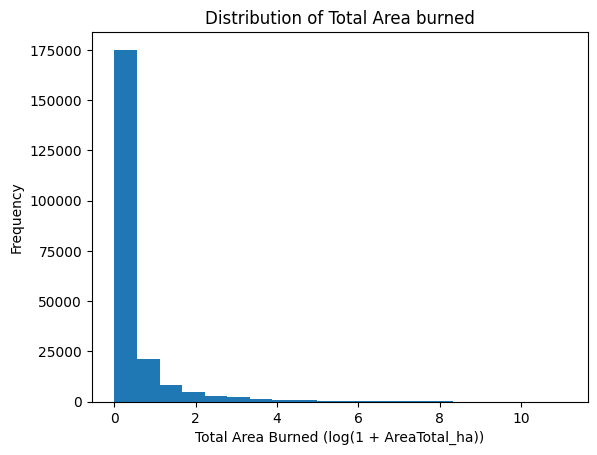

In [35]:
# Putting everything in the same scale with log since there are fires with 0 burned Area
plt.hist(np.log1p(fires["AreaTotal_ha"]), bins=20)

plt.title("Distribution of Total Area burned")

plt.xlabel("Total Area Burned (log(1 + AreaTotal_ha))")
plt.ylabel("Frequency")

plt.show()


#### Total Burned Area per Year

We've seen that 2017 had the most ocurrences so far (21006) and it also has the most burned area (539921 ha).

What's interesting is 2025. It has 8252 ocurrences, being the #5th year with most ocurrences, but it's #2nd in burned area, with 270695 ha burned.

In [36]:
total_area_burned_yearly = (
    fires_2017_2025.groupby(by="Ano")["AreaTotal_ha"]
    .agg(['mean','median','sum'])
    .round(2)
    .reset_index())
print(total_area_burned_yearly)

    Ano   mean  median        sum
0  2017  25.70    0.08  539921.00
1  2018   3.63    0.05   44577.50
2  2019   3.89    0.05   42083.92
3  2020   6.98    0.05   67169.93
4  2021   3.46    0.07   28360.01
5  2022  10.60    0.06  110097.06
6  2023   4.59    0.05   34509.21
7  2024  22.01    0.05  137651.42
8  2025  32.80    0.06  270695.11


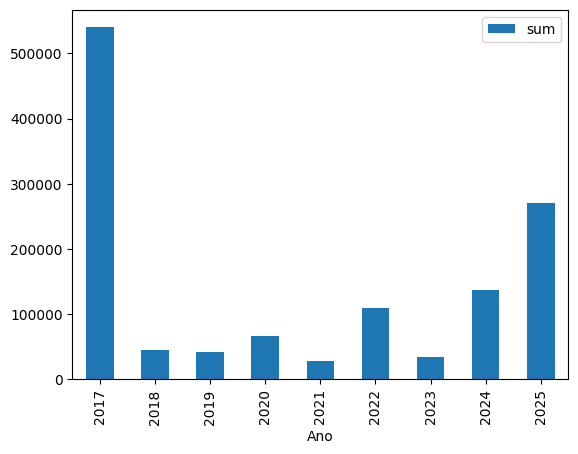

In [37]:
total_area_burned_yearly.plot(x='Ano',
                              y='sum',
                              kind='bar')

plt.show()

###  Exploring Fires from 2017 and 2025

In [38]:
top_10_fires = fires_2017_2025.nlargest(10, 'AreaTotal_ha',keep='all')
top_10_fires = top_10_fires[["Codigo_SGIF",
                             "Distrito",
                             "Concelho",
                             "AreaTotal_ha",
                             "Ano"]]
top_10_fires

,Codigo_SGIF,Distrito,Concelho,AreaTotal_ha,Ano
37744,20251075979,Coimbra,Arganil,65478.286936,2025
142090,BL2171045,Coimbra,Lousã,53618.811555,2017
37416,20251056789,Guarda,Trancoso,46917.088936,2025
142139,BL2171054,Coimbra,Arganil,37958.503115,2017
132550,BI2173957,Castelo Branco,Sertã,33639.680000,2017
142127,BI2174250,Castelo Branco,Sertã,33192.611000,2017
130108,BL4171577,Leiria,Pedrógão Grande,30358.840000,2017
150850,AG118728,Faro,Monchique,26763.825501,2018
15634,2022_05_0022298,Castelo Branco,Covilhã,24333.237905,2022
134984,BL4171971,Leiria,Alvaiázere,22824.488000,2017


In [39]:
# Calculating what percentage of yearly burned area was caused by fires with > 100 ha
 # Setting 'Ano' as the index so the indices match
total_by_year = total_area_burned_yearly.set_index("Ano")["sum"]

fires_over_100 = fires_2017_2025[fires_2017_2025["AreaTotal_ha"] > 100]
fires_over_100_by_year = fires_over_100.groupby("Ano")["AreaTotal_ha"].sum()

perc_fires_over_100 = (fires_over_100_by_year / total_by_year * 100).round(2)
print(perc_fires_over_100)

Ano
2017    93.67
2018    76.66
2019    64.79
2020    82.57
2021    53.09
2022    84.50
2023    68.73
2024    92.41
2025    95.64
dtype: float64


In [40]:
f_o_100group = fires_over_100.groupby("Ano")["AreaTotal_ha"].agg(['median', 'mean', 'sum', 'count'])
f_o_100group

,median,mean,sum,count
Ano,,,,
2017,295.427000,1873.123947,505743.465611,270
2018,250.000000,1366.855032,34171.375795,25
2019,195.743250,439.761891,27265.237224,62
2020,259.749250,840.365941,55464.152075,66
2021,193.000000,485.644203,15054.970281,31
2022,266.059292,930.306351,93030.635135,100
2023,197.256972,624.143631,23717.457984,38
2024,396.808124,1551.189697,127197.555171,82
2025,391.424563,2563.283817,258891.665538,101


In [41]:
perc_tot_ocurr_over_100 = (f_o_100group['count'] / total_ocurrences * 100)
perc_tot_ocurr_over_100

Ano
2017    1.285347
2018    0.203683
2019    0.572378
2020    0.686142
2021    0.378695
2022    0.962464
2023    0.505118
2024    1.310951
2025    1.223946
Name: count, dtype: float64

Now we can do some analysis: 

- 2017 had the **most total burned area**: 539 921ha
- 2025 saw 270 695 ha burned.

But 2025 had a bigger area burned, on average, per ocurrence:
- 2017: 25.7
- 2025: 32.8 ha 
 
The median, in both years, was low:
- 2017: 0.08 ha
- 2025: 0.06 ha

This shows that both years were dominated by small ocurrences while a small number of huge fires pull the mean up.

The percentage of burned area from fires with > 100 ha implies this:
- 2017: 93.67%
- 2025: 95.64%

In 2017, fires larger than 100 ha represented only about 1.29% of all occurrences, but accounted for approximately 93.7% of the total burned area. Similarly, in 2025, large fires represented around 1.2% of occurrences, while explaining more than 95% of the total burned area.

These results indicate that wildfire occurrence and wildfire severity are very different phenomena. Most recorded fires are small, while a small number of large events are responsible for the majority of the environmental impact.

#### Creating Classes for Burned Area

In [42]:
bins = [-0.001, 0, 0.1 , 1, 10, 100, 1000, np.inf]

lab = ['0 ha',
       '0 to 0.1 ha',
       '0.1 to 1 ha',
       '1 to 10 ha',
       '10 to 100 ha',
       '100 to 1000 ha',
       '>1000 ha']

fires_2017_2025['BurnedAreaCat'] = pd.cut(fires_2017_2025['AreaTotal_ha'],
                                          bins = bins,
                                          labels = lab,
                                          include_lowest=True)

fires_2017_2025['BurnedAreaCat'].value_counts().sort_index()

BurnedAreaCat
0 ha                227
0 to 0.1 ha       55327
0.1 to 1 ha       24527
1 to 10 ha        10561
10 to 100 ha       2920
100 to 1000 ha      618
>1000 ha            157
Name: count, dtype: int64

#### What is the most common cause for fires? 

In [43]:
fires_2017_2025['TipoCausa'].value_counts()

TipoCausa
Negligente       31480
Desconhecida     30490
Intencional      17311
Reacendimento     5578
Natural            970
Name: count, dtype: int64

In [44]:
fires_2017_2025['GrupoCausa'].value_counts()

GrupoCausa
Indeterminadas                                                            30490
Incendiarismo - Imputáveis                                                15768
Queimadas de sobrantes florestais ou agrícolas                             9765
Reacendimentos                                                             5578
Queimadas para gestão de pasto para gado                                   5418
Queimas amontoados de sobrantes florestais ou agrícolas                    4737
Acidentais - Transportes e Comunicações                                    3219
Acidentais - Maquinaria                                                    2410
Uso do fogo - Fumar                                                        2081
Acidentais - Outros                                                        1533
Uso do fogo - Queima de lixo                                               1096
Naturais                                                                    970
Incendiarismo - Sem motivação

## Monthly Analysis

### Monthly Ocurrences

In [45]:
monthly_fires = fires_2017_2025.groupby('Mes').size()
monthly_fires

Mes
1      2520
2      4607
3      5544
4      6280
5      8068
6      8629
7     15862
8     19116
9     12517
10     8834
11     1616
12      744
dtype: int64

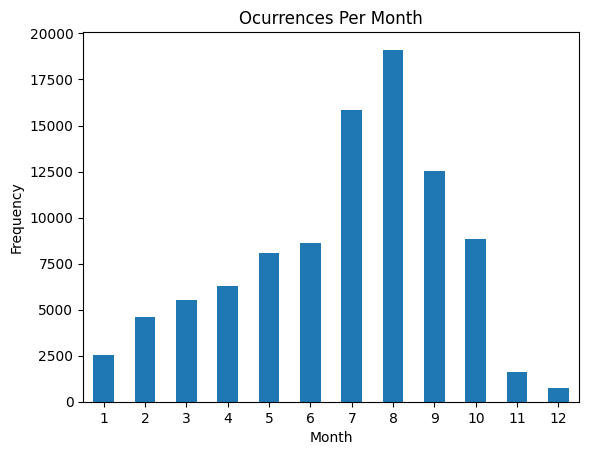

In [46]:
monthly_fires.plot(kind='bar')

plt.xticks(rotation=0)
plt.title('Ocurrences Per Month')

plt.xlabel('Month')
plt.ylabel('Frequency')

plt.show()

### Monthly Burned Area (Sum from 2017 to 2025)

In [47]:
total_monthly_burned = (
    fires_2017_2025.groupby('Mes')['AreaTotal_ha']
    .agg(['sum','mean','median']))

total_monthly_burned

,sum,mean,median
Mes,,,
1,11275.230596,4.474298,0.19295
2,11051.585093,2.398868,0.18500
3,19965.674846,3.601312,0.20000
4,14331.592888,2.282101,0.12310
5,7058.488667,0.874875,0.05000
6,70580.389079,8.179440,0.04510
7,196726.601590,12.402383,0.05000
8,441042.862686,23.071922,0.05000
9,199581.508113,15.944836,0.05000


In [48]:
# Seeing which months have fires over > 100ha

fires_over_100.groupby('Mes').size()

Mes
1      18
2      12
3      29
4      16
5       6
6      40
7     157
8     224
9     147
10    124
11      2
dtype: int64

The monthly analysis shows a clear seasonal pattern in wildfire activity. The number of recorded occurrences starts to increase from May, reaches its highest level in August, and remains relatively high until October.

However, the number of fires and their severity do not follow exactly the same pattern. For example, May recorded 8,068 occurrences but only around 7,058 hectares burned, while October had a similar number of occurrences, 8,834, but more than 300,000 hectares burned.

August stands out as the month with both the highest number of occurrences and the largest total burned area, with 19,116 recorded fires and approximately 441,043 hectares burned.

Large fires above 100 hectares are particularly concentrated between July and October, with August recording the highest number. This suggests that May may represent the beginning of the high-occurrence season, while the most severe wildfire activity is concentrated mainly between June and October.

## Geographical Analysis

In [49]:
# Which district has the most ocurrences? 

fires_2017_2025.groupby("Distrito").size().sort_values(ascending=False)



Distrito
Porto               20208
Braga                9299
Aveiro               7040
Viseu                6750
Viana do Castelo     6483
Vila Real            6274
Lisboa               6004
Santarém             5374
Setúbal              3406
Leiria               3305
Castelo Branco       3077
Bragança             3031
Coimbra              2766
Faro                 2576
Guarda               2568
Beja                 2389
Portalegre           1933
Évora                1853
dtype: int64

In [50]:
fires_2017_2025.groupby('Distrito')['AreaTotal_ha'].agg(['sum','mean','median'])

,sum,mean,median
Distrito,,,
Aveiro,51066.879026,7.253818,0.0380
Beja,22539.952122,9.434890,0.2171
Braga,49027.811489,5.272375,0.1300
Bragança,71272.667612,23.514572,0.4000
Castelo Branco,177131.154144,57.566186,0.0600
Coimbra,217513.352364,78.638233,0.0300
Faro,45281.559760,17.578245,0.0356
Guarda,185199.332067,72.118120,0.2500
Leiria,89660.175164,27.128646,0.0400


In [51]:
fires_over_100.groupby('Distrito').size().sort_values(ascending=False)

Distrito
Vila Real           105
Guarda               83
Viseu                82
Braga                75
Bragança             69
Viana do Castelo     65
Porto                53
Castelo Branco       47
Aveiro               29
Santarém             27
Beja                 26
Coimbra              26
Leiria               21
Portalegre           20
Faro                 18
Évora                14
Lisboa                9
Setúbal               6
dtype: int64

Porto records the highest number of occurrences, but districts such as Coimbra, Guarda and Castelo Branco present larger total burned areas and higher average burned area per fire. 

This indicates that regions with the most frequent fire occurrences are not necessarily the regions experiencing the most destructive fires.

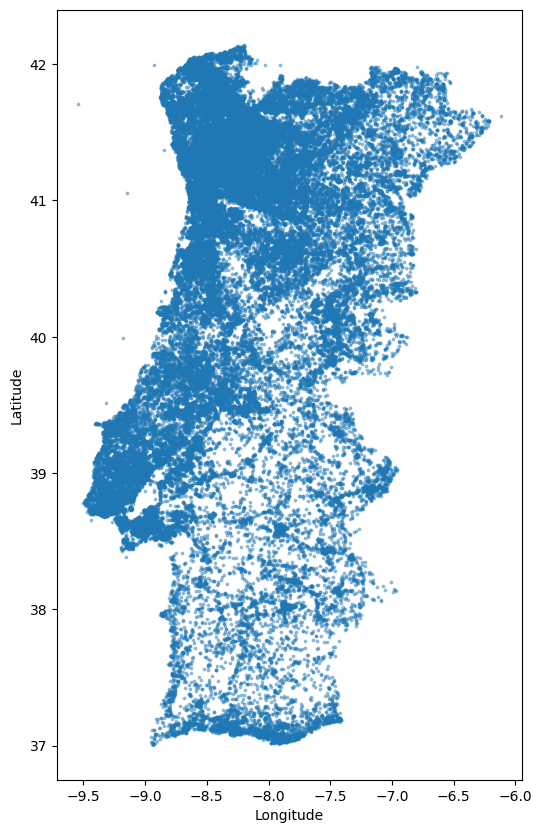

In [52]:
fires_valid_coords = fires_2017_2025[
    fires_2017_2025['Latitude'].between(36.9, 42.2) &
    fires_2017_2025['Longitude'].between(-9.6, -6.1)
]

fires_valid_coords.plot.scatter(
    x='Longitude',
    y='Latitude',
    s=3,
    alpha=0.4,
    figsize=(6,10)
    )

plt.show()

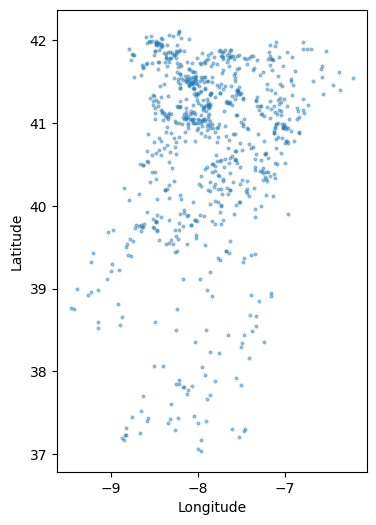

In [53]:
fires_over_100.plot.scatter(
    x='Longitude',
    y='Latitude',
    s=4,
    alpha=0.4,
    figsize=(4,6)
)
plt.show()

Since there are fires in the Atlantic Ocean, let's go from using simple functions like .between from pandas and move to the GeoPandas library.

The map of Portugal will be downloaded from **Carta Administrativa Oficial de Portugal**, accessible through: https://www.dgterritorio.gov.pt/atividades/cartografia/cartografia-tematica/caop

## Geospatial Analysis (With GeoPandas)

In [54]:
gpd.list_layers("../data/raw/CAOP_Continente_2025-gpkg/Continente_CAOP2025.gpkg")

,name,geometry_type
0,cont_areas_administrativas,Polygon
1,cont_distritos,MultiPolygon
2,cont_freguesias,MultiPolygon
3,cont_municipios,MultiPolygon
4,cont_nuts1,MultiPolygon
5,cont_nuts2,MultiPolygon
6,cont_nuts3,MultiPolygon
7,cont_trocos,LineString
8,layer_styles,NaN
9,inf_fonte_troco,NaN


In [55]:
districts = gpd.read_file(
                            "../data/raw/CAOP_Continente_2025-gpkg/Continente_CAOP2025.gpkg",
                            layer='cont_distritos')

print(f"""
Shape: \n {districts.shape} \n 
Column names: \n {districts.columns} \n 
CRS: \n {districts.crs} \n 
Head: \n {districts.head()}""")


Shape: 
 (18, 9) 
 
Column names: 
 Index(['dt', 'distrito', 'nuts1_cod', 'nuts1', 'area_ha', 'perimetro_km',
       'n_municipios', 'n_freguesias', 'geometry'],
      dtype='str') 
 
CRS: 
 EPSG:3763 
 
Head: 
    dt        distrito nuts1_cod       nuts1     area_ha  perimetro_km  \
0  01          Aveiro         1  Continente   280094.16           376   
1  02            Beja         1  Continente  1026332.49           762   
2  03           Braga         1  Continente   270615.05           351   
3  04        Bragança         1  Continente   659853.71           476   
4  05  Castelo Branco         1  Continente   662747.31           569   

   n_municipios  n_freguesias  \
0            19         174.0   
1            14          84.0   
2            14         371.0   
3            12         226.0   
4            11         128.0   

                                            geometry  
0  MULTIPOLYGON (((-44918.396 84539.049, -44943.6...  
1  MULTIPOLYGON (((21353.196 -247928.76

EPSG:3763 is the ETRS89. The fires dataset already has coordinates in this format, in the columns "X_ETRS89" and "Y_ETRS89"

<Axes: >

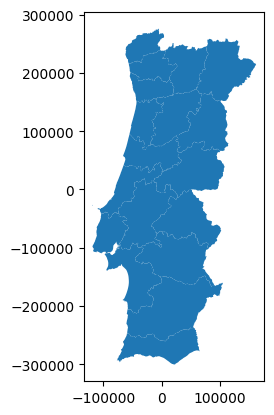

In [56]:
districts.plot()

In [57]:
portugal = districts.geometry.union_all()

# Creating GeoDataFrame from Latitude and Longitude Features and subsequently turning them into ETRS89
fires_latlon = gpd.GeoDataFrame(
    fires_2017_2025,
    geometry=gpd.points_from_xy(
        fires_2017_2025["Longitude"],
        fires_2017_2025["Latitude"]
    ),
    crs="EPSG:4326"
).to_crs("EPSG:3763")

# Creating another GeoDataFrame just for comparison
fires_etrs = gpd.GeoDataFrame(
    fires_2017_2025,
    geometry=gpd.points_from_xy(
        fires_2017_2025["X_ETRS89"],
        fires_2017_2025["Y_ETRS89"]
    ),
    crs="EPSG:3763"
)

# Checking how many coordinates are outside of Portugal in both systems
# to re-assure both coordinates systems (lat and lon; X_ETRS89 and Y_ETRS89) don't have 
# any discrepancies

latlon_inside = fires_latlon.geometry.covered_by(portugal)
etrs_inside = fires_etrs.geometry.covered_by(portugal)

print("Lat/Lon outside Portugal:", (~latlon_inside).sum())
print("ETRS89 outside Portugal:", (~etrs_inside).sum())

Lat/Lon outside Portugal: 27
ETRS89 outside Portugal: 27


In [58]:
# Checking if it's the same fires between the 2 coordinate system

outside_latlon_ids = set(
    fires_latlon.loc[~latlon_inside, "Codigo_SGIF"]
)

outside_etrs_ids = set(
    fires_etrs.loc[~etrs_inside, "Codigo_SGIF"]
)

outside_latlon_ids == outside_etrs_ids

False

In [59]:
both_outside = outside_latlon_ids & outside_etrs_ids
only_latlon_outside = outside_latlon_ids - outside_etrs_ids
only_etrs_outside = outside_etrs_ids - outside_latlon_ids

print("Outside in both:", len(both_outside))
print("Only Lat/Lon:", len(only_latlon_outside))
print("Only ETRS:", len(only_etrs_outside))

Outside in both: 26
Only Lat/Lon: 1
Only ETRS: 1


Both systems agree in 26 instances out of 94.000 records.

Since it's such a small percentage and due to the scope of this project, I decided only to keep only fire records whose ETRS89 coordinates fall within mainland Portugal's official CAOP boundary.

In [60]:
fires_clean = fires_etrs[
    fires_etrs.geometry.covered_by(portugal)
].copy()

print("Before:", len(fires_etrs))
print("After:", len(fires_clean))
print("Removed:", len(fires_etrs) - len(fires_clean))

Before: 94337
After: 94310
Removed: 27


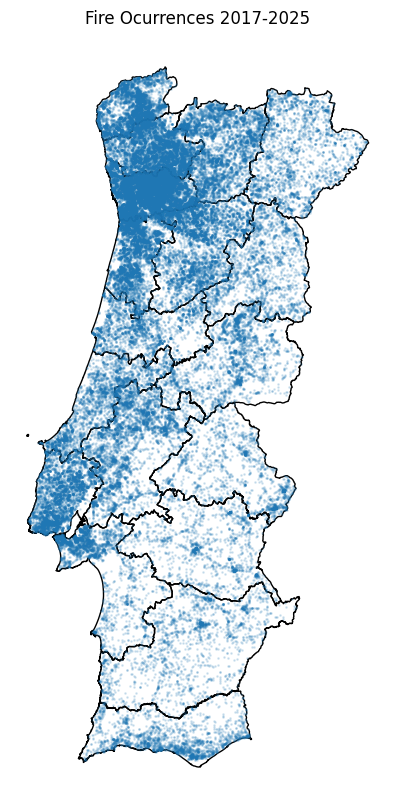

In [61]:
ax = districts.plot(
    figsize=(6, 10),
    edgecolor='black',
    facecolor='none'
)

fires_clean.plot(
    ax=ax,
    markersize=1,
    alpha=0.15
)

ax.set_title('Fire Ocurrences 2017-2025')
ax.set_axis_off()

plt.show()

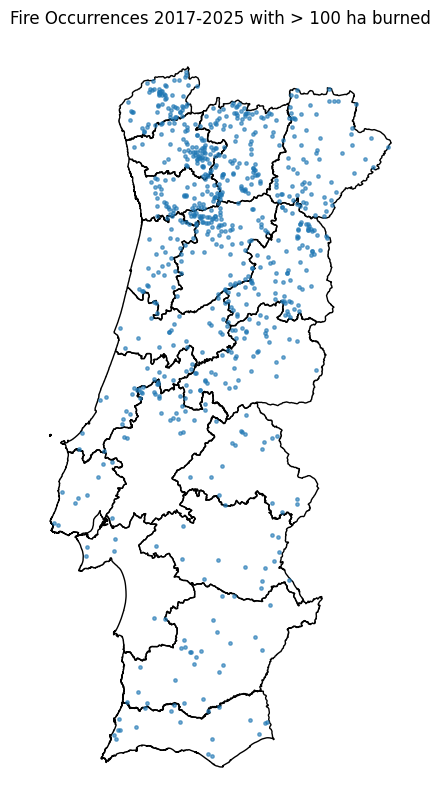

In [62]:
ax = districts.plot(
    figsize=(6, 10),
    edgecolor='black',
    facecolor='none'
)

(fires_clean[fires_clean['AreaTotal_ha'] > 100]).plot(
    ax=ax,
    markersize=6,
    alpha=0.6
)

ax.set_title('Fire Occurrences 2017-2025 with > 100 ha burned')
ax.set_axis_off()

plt.show()

In [63]:
fires_with_districts = gpd.sjoin(
    fires_clean,
    districts[['distrito', 'geometry']],
    how='left',
    predicate='within'
)

# Distrito is the one declared by ICNF (fire dataset)
# distrito is the one GeoPandas found through the coordinates

mismatch = (
    fires_with_districts["Distrito"]
    != fires_with_districts["distrito"]
)

mismatch.sum()

np.int64(10)

In [64]:
# Checking where the 10 mismatches are

fires_with_districts.loc[
    mismatch,
    [
        "Codigo_SGIF",
        "Distrito",
        "distrito",
        "Concelho"
    ]
]

,Codigo_SGIF,Distrito,distrito,Concelho
126858,TM117639,Vila Real,Porto,Vila Real
132862,TM1171041,Vila Real,Porto,Mesão Frio
137591,TM1171343,Vila Real,Braga,Ribeira de Pena
162640,BI119284,Guarda,Viseu,Gouveia
168320,DM220425,Porto,Braga,Santo Tirso
168657,DM420254,Braga,Porto,Fafe
173139,BI120354,Guarda,Viseu,Gouveia
19520,20230230312,Aveiro,Viseu,Arouca
21706,20230626263,Braga,Porto,Barcelos
26704,20240490627,Porto,Braga,Felgueiras


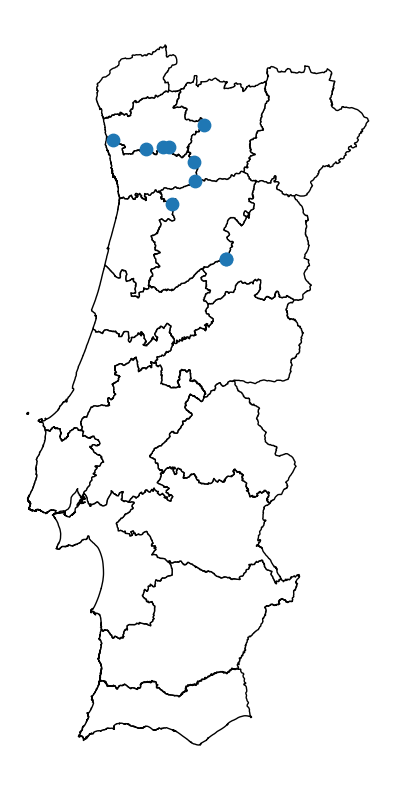

In [65]:
ax = districts.plot(
    figsize=(6, 10),
    edgecolor='black',
    facecolor= 'white'
)

fires_with_districts.loc[mismatch].plot(
    ax=ax,
    markersize=80,
)

ax.set_axis_off()

Since all 10 cases are on border limits, there is no reason to remove them for data imputation errors. These are most likely coordinate imprecisions between ICNF and the districts obtained geometrically.


In [66]:
min_x, min_y, max_x, max_y = districts.total_bounds

In [67]:
width_m = max_x - min_x
height_m = max_y - min_y

print(f" Portugal width: {width_m / 1000:.2f} km")
print(f" Portugal height: {height_m / 1000:.2f} km")

 Portugal width: 281.32 km
 Portugal height: 576.49 km


#### Deciding between 5 x 5 km grid or 10 x 10

I didn't know the size of each cell to go for. 

At this stage, I was undecided between 5x5km or 10x10km or anything in-between.

I decided to go with 5x5 since I only got 3822 cells. 

Later, it would be interesting to ask a question like "Does spatial resolution affects wildfire risk prediction?" and I will try different cell sizes.

In [68]:
# 5 x 5s 
cells_x_5 = np.ceil(width_m / 5000)
cells_y_5 = np.ceil(height_m / 5000)

total_5 = cells_x_5 * cells_y_5

print(f"Number of cells with 5 x 5s: {total_5:.0f}")

Number of cells with 5 x 5s: 6612


In [69]:
# Drawing cells of 5 x 5 km over Portugal's Mainland
cell_size = 5000 # Defining each cell size
cell_area = cell_size * cell_size

grid_cells = [] # Creating a list for the cells 

for x in np.arange(min_x, max_x, cell_size): # Starting at min_x, ending at max_x coordinates, with a step of 5km
    for y in np.arange(min_y, max_y, cell_size):

        cell = box( # Creating each cell itself
            x, # Starting at current position of x and y 
            y,
            x + cell_size, # Ending the box at x + cell step (5000m)
            y + cell_size
        )

        grid_cells.append(cell)

grid_5km = gpd.GeoDataFrame( 
    geometry=grid_cells, # Geometry is equal to the list of all the cells made
    crs=districts.crs # Using the districts crs for coordinates system
)

print(grid_5km.shape) # Output equals 6612, which is what I estimated it would be 
print(grid_5km.head())

(6612, 1)
                                            geometry
0  POLYGON ((-114191.407 -300404.804, -114191.407...
1  POLYGON ((-114191.407 -295404.804, -114191.407...
2  POLYGON ((-114191.407 -290404.804, -114191.407...
3  POLYGON ((-114191.407 -285404.804, -114191.407...
4  POLYGON ((-114191.407 -280404.804, -114191.407...


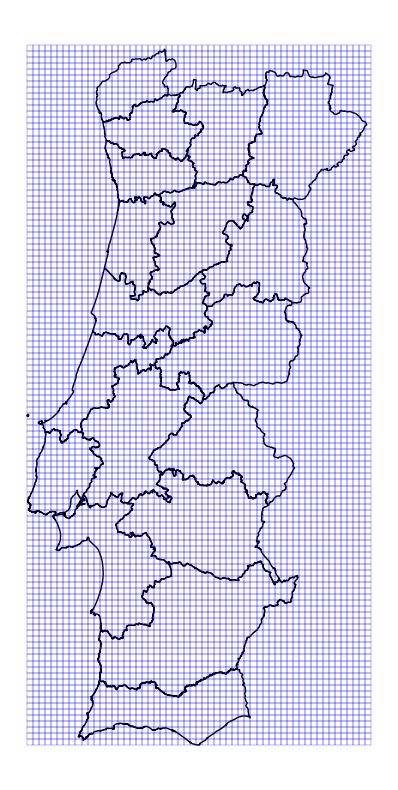

In [70]:
# Visualizing the 5 x 5 cells on the map

ax = districts.plot(
    figsize=(6, 10),
    edgecolor='black',
    facecolor='none'
)

grid_5km.plot(
    ax=ax,
    edgecolor='blue',
    facecolor='none',
    linewidth=0.2
)

ax.set_axis_off()

# ISSUE : Now we have cells over the Atlantic Ocean and Spain.

<Axes: >

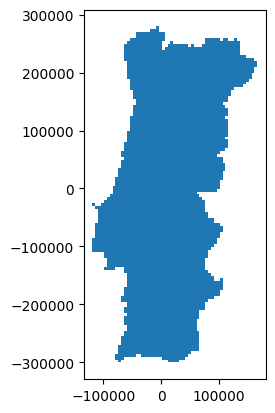

In [71]:
grid_5km_portugal = grid_5km[
    grid_5km.geometry.intersects(portugal)
].copy()

grid_5km_portugal.plot()

In [72]:
grid_5km_portugal.shape

# Went from 6612 cells to 3822 cells 

(3822, 1)

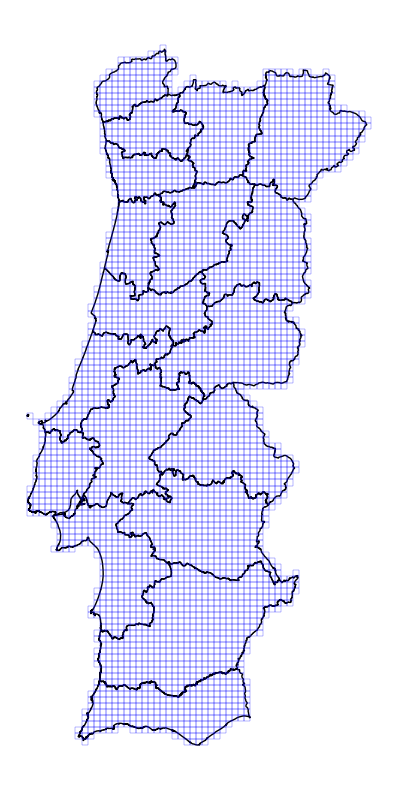

In [73]:
# Checking new grid over districts map to see if it looks ok
ax = districts.plot(
    figsize=(6, 10),
    edgecolor='black',
    facecolor='none'
)

grid_5km_portugal.plot(
    ax=ax,
    edgecolor='blue',
    facecolor='none',
    linewidth=0.2
)

ax.set_axis_off()

In [74]:
grid_5km_portugal["land_area"] = ( # Intersecting the newly created grid with portugals geometry
    grid_5km_portugal.geometry
    .intersection(portugal)
    .area
)

grid_5km_portugal["land_fraction"] = ( # Getting % of Portugals mainland covered by the new grid
    grid_5km_portugal["land_area"] / cell_area
)

In [75]:
grid_5km_portugal["land_fraction"].describe()

count    3822.000000
mean        0.932519
std         0.215397
min         0.000002
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: land_fraction, dtype: float64

Most of the cells are within Portugals limits (mean = 0.93). But we do have a minimum = 0, so there are some cells touch Portugal by a miniscule fraction.

In [76]:
(grid_5km_portugal["land_fraction"] < 0.5).sum() # Getting cells that have less than 50% their area inside Portugal

np.int64(253)

3822 cells intersect Portugal
253 (6,6% of cell grid) have less than 50% of their area inside Portugal.

#### Filtering cells without majority of land within Portugal

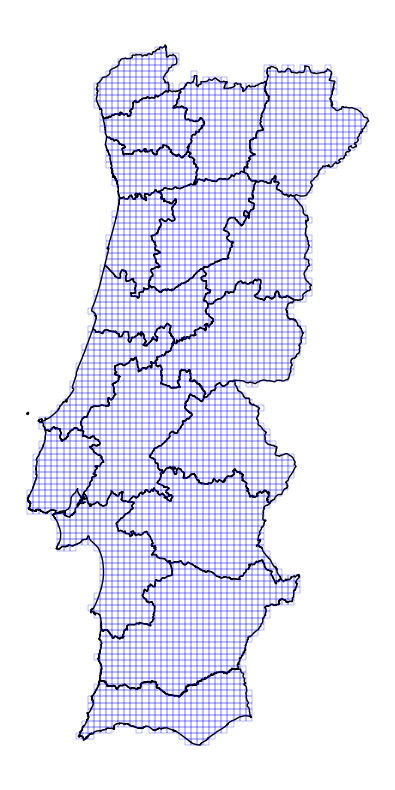

In [77]:
grid_5km_10 = grid_5km_portugal[
    grid_5km_portugal["land_fraction"] >= 0.10
].copy()

ax = districts.plot(
    figsize=(6, 10),
    edgecolor='black',
    facecolor='none'
)

grid_5km_10.plot(
    ax=ax,
    edgecolor='blue',
    facecolor='none',
    linewidth=0.2
)

ax.set_axis_off()

Initially I tried setting a threshold for the cells outside of Portugal limits but the results were a bit dubious.
There I decided to wait to get the satellite image and choose a threshold (if so) by then.

The tests and the following results were as follows:

| Threshold  | Grid Cells | Fires excluded |
| --------   | -------    | -------        |
| Centroid   | 3506       | 889            |
| 50%        | 3569       | 826            |
| 25%        | 3643       | 258            |
| 10%        | 3710       | 67             |



#### Creating a cell ID for each cell 

In [78]:
grid_5km_portugal["cell_id"] = [
    f"PT_{i:04d}" 
    for i in range(1, len(grid_5km_portugal) + 1)
]

grid_5km_portugal["cell_id"].head()

38    PT_0001
39    PT_0002
40    PT_0003
41    PT_0004
42    PT_0005
Name: cell_id, dtype: str

Now we can associate 

Fire - date - grid cell

In [79]:
fires_with_cells = gpd.sjoin(
    fires_clean,
    grid_5km_portugal[["cell_id", "geometry"]],
    how="left",
    predicate="within"
)

fires_with_cells[
    ["Codigo_SGIF", "DataHoraAlerta", "AreaTotal_ha", "cell_id"]
].head(10)

,Codigo_SGIF,DataHoraAlerta,AreaTotal_ha,cell_id
123398,DM4171,2017-01-01 00:12:00,0.0100,PT_1192
123399,BL3172,2017-01-01 00:21:00,0.0010,PT_1164
123400,RO2171,2017-01-01 00:22:00,0.0195,PT_0003
123401,BL3171,2017-01-01 00:30:00,0.0750,PT_1172
123402,DM4173,2017-01-01 12:38:00,0.0100,PT_0964
123403,DM2175,2017-01-01 14:00:00,0.1500,PT_0736
123404,DM2174,2017-01-01 14:21:00,0.0100,PT_0954
123405,BL3178,2017-01-01 14:40:00,0.0050,PT_0944
123406,RO2176,2017-01-01 14:48:00,3.9300,PT_0087
123407,TM1172,2017-01-01 15:53:00,0.1000,PT_2410


In [80]:
fires_with_cells.head()

,Codigo_SGIF,Codigo_ANEPC,Ano,Mes,Dia,Hora,AreaPov_ha,AreaMato_ha,AreaAgric_ha,AreaTotal_ha,...,BUI,CodCausa,TipoCausa,GrupoCausa,DescricaoCausa,FonteAlerta,BurnedAreaCat,geometry,index_right,cell_id
123398,DM4171,2017030000006,2017,1,1,0,0.000,0.0100,0.0,0.0100,...,8.846614,60.0,Desconhecida,Indeterminadas,Indeterminadas,Populares,0 to 0.1 ha,POINT (-20929.952 224145.378),2308,PT_1192
123399,BL3172,2017010000004,2017,1,1,0,0.000,0.0010,0.0,0.0010,...,13.827160,610.0,Desconhecida,Indeterminadas,Indeterminadas - Prova material,CCO,0 to 0.1 ha,POINT (-23033.937 82104.865),2280,PT_1164
123400,RO2171,2017110000013,2017,1,1,0,0.000,0.0195,0.0,0.0195,...,11.686807,630.0,Desconhecida,Indeterminadas,Indeterminadas - Outras informações,112,0 to 0.1 ha,POINT (-117597.432 -97898.322),40,PT_0003
123401,BL3171,2017010000007,2017,1,1,0,0.075,0.0000,0.0,0.0750,...,7.991686,6.0,Desconhecida,Indeterminadas,Indeterminadas,117,0 to 0.1 ha,POINT (-20500.392 120596.877),2288,PT_1172
123402,DM4173,2017030000139,2017,1,1,12,0.000,0.0100,0.0,0.0100,...,9.342361,60.0,Desconhecida,Indeterminadas,Indeterminadas,117,0 to 0.1 ha,POINT (-31570.297 202639.933),2072,PT_0964


In [81]:
fires_with_cells = fires_with_cells.drop(columns="index_right")

#### Visualizing fires on cells

In [82]:
# How many fires ocurred per cell between 2017-2025 ? 

fires_per_cell = (
    fires_with_cells
    .groupby("cell_id")
    .size()
    .rename('fire_count')
)
print(fires_per_cell.describe())

print(fires_per_cell.nlargest(10))

count    3511.000000
mean       26.861293
std        47.991059
min         1.000000
25%         4.000000
50%        11.000000
75%        28.000000
max       661.000000
Name: fire_count, dtype: float64
cell_id
PT_1182    661
PT_1070    481
PT_1295    460
PT_1296    459
PT_1520    432
PT_0956    402
PT_1183    393
PT_0955    374
PT_1407    374
PT_1521    373
Name: fire_count, dtype: int64


The above groupby only shows cells where at least 1 fire ocurred, meaning cells with 0 fires dont show up.

In [83]:
cells_with_fires = len(fires_per_cell)
cells_without_fires = len(grid_5km_portugal) - cells_with_fires

print("Cells with fires:", cells_with_fires)
print("Cells without fires:", cells_without_fires)

Cells with fires: 3511
Cells without fires: 311


From 2017 to 2025 , only 311 out of 3511 cells had 0 ocurrences.

In [84]:
grid_fire_counts = grid_5km_portugal.merge(
    fires_per_cell,
    left_on="cell_id",
    right_index=True,
    how="left"
)

grid_fire_counts["fire_count"] = (
    grid_fire_counts["fire_count"].fillna(0)
)

grid_fire_counts[["cell_id", "fire_count"]].head()

,cell_id,fire_count
38,PT_0001,0.0
39,PT_0002,12.0
40,PT_0003,30.0
41,PT_0004,23.0
42,PT_0005,1.0


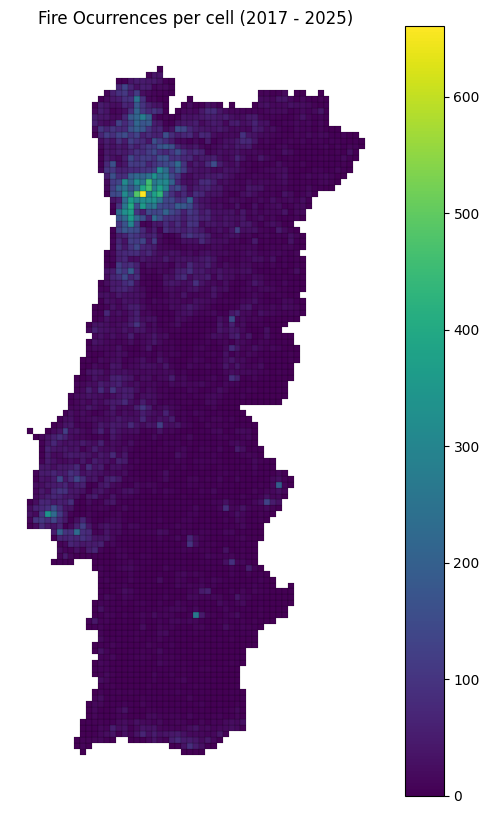

In [85]:
ax = grid_fire_counts.plot(
    column="fire_count",
    figsize=(6, 10),
    legend=True,
    edgecolor='black',
    linewidth=0.1
)

ax.set_title("Fire Ocurrences per cell (2017 - 2025)")
ax.set_axis_off()

In [86]:
# Some cells are dominating the map. Trying to draw it again with log

grid_fire_counts["log_fire_count"] = np.log1p(
    grid_fire_counts["fire_count"]
)

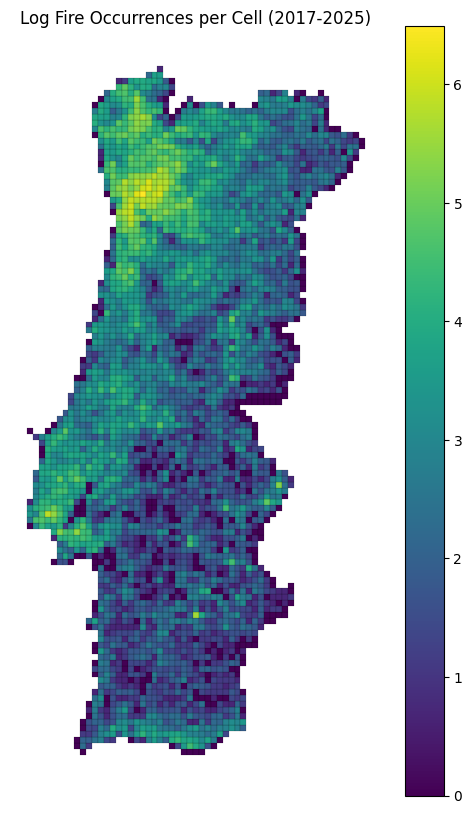

In [87]:
ax = grid_fire_counts.plot(
    column="log_fire_count",
    figsize=(6, 10),
    legend=True,
    edgecolor='black',
    linewidth=0.1
)

ax.set_title("Log Fire Occurrences per Cell (2017-2025)")
ax.set_axis_off()

## Creating the final dataset

First, let's create a column with the date of the fire, normalized, so it's used for reference.

In [88]:
fires_with_cells["fire_date"] = (
    fires_with_cells["DataHoraAlerta"]
    .dt.normalize()
)

In [89]:
fires_with_cells.head(2)

,Codigo_SGIF,Codigo_ANEPC,Ano,Mes,Dia,Hora,AreaPov_ha,AreaMato_ha,AreaAgric_ha,AreaTotal_ha,...,BUI,CodCausa,TipoCausa,GrupoCausa,DescricaoCausa,FonteAlerta,BurnedAreaCat,geometry,cell_id,fire_date
123398,DM4171,2017030000006,2017,1,1,0,0.0,0.010,0.0,0.010,...,8.846614,60.0,Desconhecida,Indeterminadas,Indeterminadas,Populares,0 to 0.1 ha,POINT (-20929.952 224145.378),PT_1192,2017-01-01
123399,BL3172,2017010000004,2017,1,1,0,0.0,0.001,0.0,0.001,...,13.827160,610.0,Desconhecida,Indeterminadas,Indeterminadas - Prova material,CCO,0 to 0.1 ha,POINT (-23033.937 82104.865),PT_1164,2017-01-01


Next, let's create the reference weeks. It'll be useful to use ISO weeks in the future.

#### Temporal Scope: May–October

Although the original fire records from ICNF cover the full calendar year, the modelling dataset will focus on **reference dates between May and October**.

Between 2017 and 2025, **77.4% of all recorded fire occurrences** happened between may and october. This period was also responsible for **more than 95% of the total burned area**, showing that the large majority of wildfire activity happens within these six months.

Restricting the modelling period also helps reduce the number of negative observations. During the wetter and more humid winter months, wildfires are substantially lower. Including a large number of these observations would increase class imbalance and make model evaluation appear artificially easier, without necessarily improving the model's ability to differentiate between higher and lower-risk conditions during the main fire season.

There is also satellite data. Sentinel-2 observations are affected by clouds, meaning that valid cloud-free observations are not available at perfectly regular intervals. During winter, there is more cloud coverage which may further reduce the availability of recent usable imagery.

Therefore, the modelling framework is:

- **Study period:** 2017–2025
- **Prediction season:** may–october
- **Temporal resolution:** weekly
- **Prediction horizon:** 7 days (`fire_next_7_days`)

Also, limiting the **reference dates** to may to october does not mean that observations outside this period will be discarded.  Meteorological and/or satellite data outside this period may still be useful to construct features such as precipitation over the previous 30 days, trends and the most recent valid Sentinel-2 observation.

When it comes to reference dates, to avoid ambiguity, I decided to go for ISO weeks. 

ISO weeks start on Mondays and end on Sundays.

A reference date column will be created to be compared against previous information gathered leading up to that week.

For example: 

- reference_date: 
    - 2024-07-15

- Features: 
    - data ≤ 2024-07-14
- Target:  
    - fires from 2024-07-15 2024-07-21
    - fire_next_7_days = 1 if there was a fire

In [90]:
reference_dates = pd.date_range(
    start="2017-05-01",
    end="2025-10-31",
    freq="W-MON"
)

reference_dates = reference_dates[
    reference_dates.month.isin(range(5,11))
]

weekly_calendar = pd.DataFrame({
    "reference_date": reference_dates
})

iso = weekly_calendar["reference_date"].dt.isocalendar()

weekly_calendar["iso_year"] = iso["year"]
weekly_calendar["iso_week"] = iso["week"]

In [91]:
print(f"\n Weekly Calendar head: \n {(weekly_calendar.head(10))}")
print(f"\n Weekly Calendar tail: \n {weekly_calendar.tail(10)}")
print(f"\n Length of Weekly Calendar: \n {len(weekly_calendar)}")


 Weekly Calendar head: 
   reference_date  iso_year  iso_week
0     2017-05-01      2017        18
1     2017-05-08      2017        19
2     2017-05-15      2017        20
3     2017-05-22      2017        21
4     2017-05-29      2017        22
5     2017-06-05      2017        23
6     2017-06-12      2017        24
7     2017-06-19      2017        25
8     2017-06-26      2017        26
9     2017-07-03      2017        27

 Weekly Calendar tail: 
     reference_date  iso_year  iso_week
227     2025-08-25      2025        35
228     2025-09-01      2025        36
229     2025-09-08      2025        37
230     2025-09-15      2025        38
231     2025-09-22      2025        39
232     2025-09-29      2025        40
233     2025-10-06      2025        41
234     2025-10-13      2025        42
235     2025-10-20      2025        43
236     2025-10-27      2025        44

 Length of Weekly Calendar: 
 237


There are dates that go beyond October. 
For example, the last reference date: 

- 2025-10-27

If we're trying to predict (`fire_next_7_days`) our target would be from 27 oct to 2nd of nov. 

Let's make it so the end of our target is within the may - oct period.

In [92]:
weekly_calendar['target_end'] = (
    weekly_calendar["reference_date"] + pd.Timedelta(days=6)
)

weekly_calendar = (weekly_calendar[
    weekly_calendar["target_end"].dt.month.isin(range(5,11))
])

weekly_calendar = weekly_calendar.reset_index(drop=True)

print(f"\n Weekly Calendar tail: \n {weekly_calendar.tail(10)}")
print(f"\n Length of Weekly Calendar: \n {len(weekly_calendar)}")


 Weekly Calendar tail: 
     reference_date  iso_year  iso_week target_end
219     2025-08-18      2025        34 2025-08-24
220     2025-08-25      2025        35 2025-08-31
221     2025-09-01      2025        36 2025-09-07
222     2025-09-08      2025        37 2025-09-14
223     2025-09-15      2025        38 2025-09-21
224     2025-09-22      2025        39 2025-09-28
225     2025-09-29      2025        40 2025-10-05
226     2025-10-06      2025        41 2025-10-12
227     2025-10-13      2025        42 2025-10-19
228     2025-10-20      2025        43 2025-10-26

 Length of Weekly Calendar: 
 229


#### Cartesian Product

In [93]:
# Getting each cell_id

cells_id = grid_5km_portugal[['cell_id']].copy()

In [94]:
model_dataset = cells_id.merge(
    weekly_calendar,
    how="cross"
)

print(f"\n Dataset Head: \n {model_dataset.head(10)}")
print(f"\n Dataset Shape: \n {model_dataset.shape}")


 Dataset Head: 
    cell_id reference_date  iso_year  iso_week target_end
0  PT_0001     2017-05-01      2017        18 2017-05-07
1  PT_0001     2017-05-08      2017        19 2017-05-14
2  PT_0001     2017-05-15      2017        20 2017-05-21
3  PT_0001     2017-05-22      2017        21 2017-05-28
4  PT_0001     2017-05-29      2017        22 2017-06-04
5  PT_0001     2017-06-05      2017        23 2017-06-11
6  PT_0001     2017-06-12      2017        24 2017-06-18
7  PT_0001     2017-06-19      2017        25 2017-06-25
8  PT_0001     2017-06-26      2017        26 2017-07-02
9  PT_0001     2017-07-03      2017        27 2017-07-09

 Dataset Shape: 
 (875238, 5)


Next step is to match each fire with their respective reference date.

Since our reference dates start on a monday, all we have to do is get the day of the week from each fire and subtract it from itself to get to monday. 

Monday = 0 

So if a fire ocurred on a wednesday (2), we subtract 2 from the date to get to monday's date.

In [95]:
# I'll use fires_with_cells since it already has the fire date associated with each cell_id

fires_with_cells["reference_date"] = (
    fires_with_cells["fire_date"] - pd.to_timedelta(
        fires_with_cells["fire_date"].dt.weekday,
        unit="D"
    )
)

fires_with_cells[
    ["fire_date", "reference_date", "cell_id"]
].head(10)

,fire_date,reference_date,cell_id
123398,2017-01-01,2016-12-26,PT_1192
123399,2017-01-01,2016-12-26,PT_1164
123400,2017-01-01,2016-12-26,PT_0003
123401,2017-01-01,2016-12-26,PT_1172
123402,2017-01-01,2016-12-26,PT_0964
123403,2017-01-01,2016-12-26,PT_0736
123404,2017-01-01,2016-12-26,PT_0954
123405,2017-01-01,2016-12-26,PT_0944
123406,2017-01-01,2016-12-26,PT_0087
123407,2017-01-01,2016-12-26,PT_2410


There have been multiple fires on the same cell on the same week, even on the same day.

For the model, it only matters if there was a fire on the next 7 days.

With this groupby by cell x week , the dataset stops tracking "ocurrences by fire" to "ocurrences by cell x week" with the count of how many fires in that week 


In [96]:
weekly_fires = (
    fires_with_cells
    .groupby(["cell_id", "reference_date"])
    .size()
    .reset_index(name="fire_count_week")
)

print(f"\n Dataset Head: \n {weekly_fires.head(10)}")
print(f"\n Dataset Shape: \n {weekly_fires.shape}")


 Dataset Head: 
    cell_id reference_date  fire_count_week
0  PT_0002     2018-08-20                1
1  PT_0002     2018-09-03                1
2  PT_0002     2018-10-01                3
3  PT_0002     2019-06-24                1
4  PT_0002     2019-09-30                1
5  PT_0002     2020-07-13                1
6  PT_0002     2023-05-15                1
7  PT_0002     2024-07-22                2
8  PT_0002     2025-06-30                1
9  PT_0003     2016-12-26                1

 Dataset Shape: 
 (67375, 3)


#### Merging

With a left merge on weekly_fires, which only has reference dates from may to october, all of the fires that ocurred outside of this period will not be joining this final dataset.

In [97]:
model_dataset = model_dataset.merge(
    weekly_fires,
    on=["cell_id", "reference_date"],
    how="left"
)

print(f"\n Dataset Head: \n {model_dataset.head(10)}")
print(f"\n Dataset Shape: \n {model_dataset.shape}")
print(f"\n Dataset NAs: \n {model_dataset['fire_count_week'].isna().sum()}")


 Dataset Head: 
    cell_id reference_date  iso_year  iso_week target_end  fire_count_week
0  PT_0001     2017-05-01      2017        18 2017-05-07              NaN
1  PT_0001     2017-05-08      2017        19 2017-05-14              NaN
2  PT_0001     2017-05-15      2017        20 2017-05-21              NaN
3  PT_0001     2017-05-22      2017        21 2017-05-28              NaN
4  PT_0001     2017-05-29      2017        22 2017-06-04              NaN
5  PT_0001     2017-06-05      2017        23 2017-06-11              NaN
6  PT_0001     2017-06-12      2017        24 2017-06-18              NaN
7  PT_0001     2017-06-19      2017        25 2017-06-25              NaN
8  PT_0001     2017-06-26      2017        26 2017-07-02              NaN
9  PT_0001     2017-07-03      2017        27 2017-07-09              NaN

 Dataset Shape: 
 (875238, 6)

 Dataset NAs: 
 825098


#### Applying the target 

In [98]:
model_dataset["fire_count_week"] = (
    model_dataset["fire_count_week"]
    .fillna(0)
    .astype(int)
)

# Turning multiple ocurrences within the same week into 1 (binary)
model_dataset["fire_next_7_days"] = (
    model_dataset["fire_count_week"] > 0
).astype(int)

print(f"\n Target Value Counts: \n {model_dataset['fire_next_7_days'].value_counts()}")
print(f"\n Target Value Counts Normalized: \n {model_dataset['fire_next_7_days'].value_counts(normalize=True)}")


 Target Value Counts: 
 fire_next_7_days
0    825098
1     50140
Name: count, dtype: int64

 Target Value Counts Normalized: 
 fire_next_7_days
0    0.942713
1    0.057287
Name: proportion, dtype: float64


There are a total of **875,238** observations:

- **`No Fire` (0)** : 825,098 (94.27%)

- **`Fire` &nbsp; &nbsp; &nbsp; (1)** : 50,140  &nbsp; (5.73%)

With this information, we have **class imbalance** which will need some preparations going forward:

- When **training** the model, it should class weights, meaning that when it makes a mistake on `Fire`, it should 'pay more'
- The **validation** and test sets should reflect the real class imbalance, not let it be a different percentage than reality.
- When **evaluating** model perfomance, we know that **accuracy** is not a good metric. Because if we have a 'dumb model' that only guesses `No Fire` (0), it'll have 94% accuracy.


In [99]:
# Final look into the model_dataset
model_dataset

,cell_id,reference_date,iso_year,iso_week,target_end,fire_count_week,fire_next_7_days
0,PT_0001,2017-05-01,2017,18,2017-05-07,0,0
1,PT_0001,2017-05-08,2017,19,2017-05-14,0,0
2,PT_0001,2017-05-15,2017,20,2017-05-21,0,0
3,PT_0001,2017-05-22,2017,21,2017-05-28,0,0
4,PT_0001,2017-05-29,2017,22,2017-06-04,0,0
...,...,...,...,...,...,...,...
875233,PT_3822,2025-09-22,2025,39,2025-09-28,0,0
875234,PT_3822,2025-09-29,2025,40,2025-10-05,0,0
875235,PT_3822,2025-10-06,2025,41,2025-10-12,0,0
875236,PT_3822,2025-10-13,2025,42,2025-10-19,0,0


In [100]:
target_by_year = (
    model_dataset
    .groupby("iso_year")["fire_next_7_days"]
    .agg(["sum", "count", "mean"])
    .round(2)
)

target_by_year

,sum,count,mean
iso_year,,,
2017,9280,99372,0.09
2018,5973,95550,0.06
2019,6063,95550,0.06
2020,5828,95550,0.06
2021,4514,99372,0.05
2022,5261,99372,0.05
2023,3996,99372,0.04
2024,3880,95550,0.04
2025,5345,95550,0.06


#### Saving the Model

This first dataset will be used for validation, auditing and possible debugging, therefore it will retain some columns that will be removed before making the training set.


In [108]:
model_dataset.to_parquet(
    "../data/interim/model_dataset_weekly.parquet",
    engine="pyarrow",
    index=False
)

In [109]:
saved_dataset = pd.read_parquet(
    "../data/interim/model_dataset_weekly.parquet"
)

print(saved_dataset.shape)
print(saved_dataset.dtypes)

(875238, 7)
cell_id                        str
reference_date      datetime64[us]
iso_year                    UInt32
iso_week                    UInt32
target_end          datetime64[us]
fire_count_week              int64
fire_next_7_days             int64
dtype: object


## What's Next ?

Next, I will get Meteorological data and will cross it with this dataset to create the dataset before training. 

The options are: 

- ERA5-LAND
- IPMA

Both services provide historical datasets.

ERA5-LAND provides global coverage, hourly data and resolutions by approx 9km.

IPMA, on the other hand, has ~200 stations scattered throughout Portugal, which means some cells have great coverage while others would need interpolation or just not good results.

Since this data will be a core feature of every model, I want to get as much reliable data as possible so **ERA5-LAND** is my go-to choice.

### 5 km Grid vs ERA5-Land Resolution

ERA5-Land has a native spatial resolution of **9 km**. When accessed through Google Earth Engine (GEE), the dataset is provided at a pixel size of **11 km**. This is broader than the **5 x 5 km grid** currently used in this project.

At first, this raised the question of whether the grid should also be changed to 10 × 10 km to match the ERA5-Land data.

A 10 x 10 km cell covers:

- **100 km^2**, compared with
- **25 km^2** for a 5 x 5 km cell.

Therefore, changing from 5 km to 10 km would make each spatial prediction unit four times larger.

This would meet with ERA5-Land data, but would reduce the spatial detail from the other data sources:

- ICNF wildfire records have precise geographic coordinates.
- Sentinel-2 images have a much finer spatial resolution (10–20m)
- A wildfire occurring in a small portion of a 10 x 10 km cell would label the entire 100 km^2 cell as positive.

### Different data sources can have different spatial resolutions

With a 5 km grid, several neighbouring cells may receive similar - or the same - ERA5-Land meteorological data. This is acceptable because the different data sources represent processes occurring at different spatial scales:

- **ERA5-Land** provides the broader meteorological context.
- **Sentinel-2** provides more local information about vegetation.
- **ICNF** provides the location and timing of observed wildfires.

For example, neighbouring 5 km cells may experience approximately the same temperature and precipitation conditions while having substantially different vegetation characteristics.

This distinction is particularly relevant to the objective of the project: evaluating whether information about **vegetation obtained from satellite imagery adds predictive value beyond meteorological conditions alone**.

### Implication for the models

For example, two nearby cells could have almost identical meteorological features:

- temperature
- precipitation
- soil moisture
- wind

while only one of them experiences a wildfire.

Later models that include Sentinel-2 vegetation information may be able to differentiate these cells using more spatially detailed information such as NDVI, NDMI and multispectral imagery.

This creates an interesting progression on this project:

1. **Climatological baseline**
2. **Weather-only model**
3. **Weather + vegetation indices**
4. **Satellite imagery + weather**